# Imports

In [29]:
# # use a python 3.11 environment, and install dynamiqs >= 0.3.0

# uncomment and run the line below once to install the required dependencies. You can also install these packages in your terminal using pip.
!pip install "dynamiqs>=0.3.0" cmaes scipy

/opt/homebrew/Cellar/python@3.11/3.11.15_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [30]:

import dynamiqs as dq
import jax.numpy as jnp
from matplotlib import pyplot as plt

from jax import vmap, jit
import jax
import numpy as np
from cmaes import SepCMA

from scipy.optimize import curve_fit
from scipy.optimize import least_squares

# dq.set_progress_meter(False)

In [31]:
# model: y = A * exp(-t/tau) + C
def model(p, t):
    A, tau, C = p
    return A * jnp.exp(-t/tau) + C

def residuals(p, x, y):
    return model(p, x) - y

def robust_exp_fit(x, y):
    A0 = y.max() - y.min()
    C0 = y.min()
    tau0 = x.max() - x.min()
    p0 = [A0, tau0, C0]

    res = least_squares(
        residuals,
        p0,
        args=(x, y),
        bounds=([0, 0, -jnp.inf], [jnp.inf, jnp.inf, jnp.inf]),
        loss="huber",
        f_scale=0.1,
    )

    return {
        "popt": res.x,
        "y_fit": model(res.x, x),
    }


In [32]:
def loss_fn_AI(Tz, Tx, C, ratio_weight=100.0,
            Tx_reward=1.0, Tz_reward=1.0,
            eps=1e-8):
    ratio_error = (Tz / (Tx + eps) - C) ** 2

    reward = Tx_reward * Tx + Tz_reward * Tz

    return ratio_weight * ratio_error - reward

def loss_fn_norm(Tz, Tx, C, ratio_weight=100.0, 
            reward_weight=1.0, eps=1e-8, p=3):
    
    ratio_error = jnp.square(Tx / (Tz + eps) - C)
    
    reward = jnp.linalg.norm(jnp.array([Tz, Tx]), ord=p)

    return ratio_weight * ratio_error - reward * reward_weight


cost_fun = [loss_fn_norm, loss_fn_AI]

In [33]:
# super params
na = 15 # memory dim
nb = 5 # buffer dim
kappa_b = 10 # MHz
kappa_a = 1 # MHz
tfinal = 200
mu = 3

# select cost function
cost_select = 0

@jit
def simul(x):
    eps_d, g_2 = x[0], x[1]
    # alpha estimation
    eps_2 = 2 * g_2 * eps_d / kappa_b
    kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b
    alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

    # basis states
    g_state = dq.coherent(na, alpha_estimate)
    e_state = dq.coherent(na, -alpha_estimate)

    # annihilation ops
    a = dq.tensor(dq.destroy(na), dq.eye(nb))
    b = dq.tensor(dq.eye(na), dq.destroy(nb))


    H = jnp.conj(g_2)*(a @ a @ dq.dag(b)) + g_2 *(dq.dag(a) @ dq.dag(a) @ b) - eps_d *dq.dag(b) - jnp.conj(eps_d)* b

    loss_b = jnp.sqrt(kappa_b) * b
    loss_a = jnp.sqrt(kappa_a) * a

    tsave = jnp.linspace(0, tfinal, 100)

    g_state = dq.coherent(na, alpha_estimate)
    e_state = dq.coherent(na, -alpha_estimate)

    basis = {
        "+z": g_state,
        "-z": e_state,
        "+x": (g_state + e_state) / jnp.sqrt(2),
        "-x": (g_state - e_state) / jnp.sqrt(2),
        "+y": (g_state + 1j*e_state) / jnp.sqrt(2),
        "-y": (g_state - 1j*e_state) / jnp.sqrt(2),
    }

    sx = (1j * jnp.pi * a.dag() @ a).expm()
    x = a + a.dag()
    p = a - a.dag()
    sz = g_state @ g_state.dag() - e_state @ e_state.dag()
    sz = dq.tensor(sz, dq.eye(nb))

    psi0 = dq.tensor(basis["+z"], dq.fock(nb,0)) # initial state

    return dq.mesolve(
        H, 
        [loss_b, loss_a], 
        psi0, 
        tsave, 
        options=dq.Options(progress_meter=False),
        exp_ops=[sx, x, p, sz]
    )

INVALID_REWARD = 1e9

def solve(eps_d, g_2):
    eps_2 = 2 * g_2 * eps_d / kappa_b
    kappa_2 = 4 * jnp.abs(g_2)**2 / kappa_b

    if g_2 == 0:
        return INVALID_REWARD

    alpha_arg = 2 / kappa_2 * (eps_2 - kappa_a / 4)

    if alpha_arg <= 0:
        return INVALID_REWARD


    res = simul(jnp.array([eps_d, g_2]))
    
    sx = res.expects[0,:].real
    x = res.expects[1,:].real
    p = res.expects[2,:].real
    sz = res.expects[3,:].real
    ts = res.tsave

    y = jnp.hypot(x, p)
    x = ts
    fit = robust_exp_fit(x, y)
    Tz = fit["popt"][1]

    y = sx
    x = ts
    fit = robust_exp_fit(x, y)
    Tx = fit["popt"][1]

    return cost_fun[cost_select](Tz, Tx, mu)

/Users/leoniekarl/Desktop/Hackathon/alice-bob-eth-quantum-hackathon-2026/jax-metal-env/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


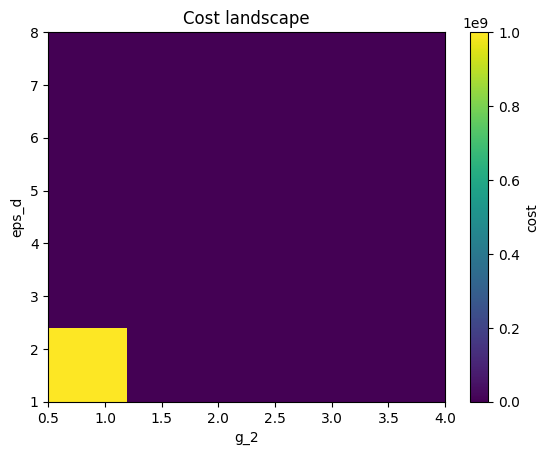

In [34]:
# tunable params (keeping them real for now)
eps_d = jnp.linspace(1.0, 8.0, 5)
g_2 = jnp.linspace(0.5, 4.0, 5)

E, G = jnp.meshgrid(eps_d, g_2, indexing="ij")

# simul_vmap = jax.vmap(
#     jax.vmap(solve, in_axes=(0, None)),  # sweep eps_d
#     in_axes=(None, 0)                    # sweep g_2
# )

C_grid = np.zeros((len(eps_d), len(g_2)))
for i, ed in enumerate(eps_d):
    for j, g2 in enumerate(g_2):
        C_grid[i, j] = solve(ed, g2)

plt.figure()
plt.imshow(
    C_grid,
    origin="lower",
    aspect="auto",
    extent=[
        g_2.min(), g_2.max(),
        eps_d.min(), eps_d.max()
    ],
)

plt.colorbar(label="cost")
plt.xlabel("g_2")
plt.ylabel("eps_d")
plt.title("Cost landscape")
plt.show()

In [35]:
BATCH_SIZE = 12
N_EPOCHS = 20
N_KNOBS = 2


# SYNTHETIC DRIFT
# ----------------------------------------
# amp_factor_delta_drift_func = lambda ep: 0.8 * jnp.sin(2 * jnp.pi * 0.01 * ep)
# ----------------------------------------


# ----------------------------------------
# CMA-ES setup
# ----------------------------------------

mean0 = jnp.array([0.7, 2.0])    # start near optimum
sigma0 = 0.2                     # exploration scale

optimizer = SepCMA(
    mean=mean0,
    sigma=sigma0,
    bounds=jnp.array([
        [-1.0, 1.0],    # amp_factor bounds
        [-5.0, 5.0],   # freq_delta_MHz bounds
    ]),
    population_size=BATCH_SIZE,
    seed=0,
)

# ----------------------------------------
# Logging
# ----------------------------------------
mean_history = []
std_history = []
reward_history = []
reward_std_history = []
drift_history = []

# ----------------------------------------
# Training loop
# ----------------------------------------
for epoch in range(N_EPOCHS):
    solutions = []

    # drift_history.append([amp_factor_delta_drift_func(epoch), 0.0])

    # Sample population
    xs = []
    for _ in range(optimizer.population_size):
        xs.append(jnp.array(optimizer.ask().tolist()))

    xs = jnp.array(xs)
  
    rewards = jnp.array([solve(float(xs[j, 0]), float(xs[j, 1])) for j in range(len(xs))])

    # Format solutions
    solutions = []
    for j in range(len(xs)):
        solutions.append((xs[j][:N_KNOBS], rewards[j]))

    optimizer.tell(solutions)

    # Log
    mean_history.append(jnp.mean(xs[:,:N_KNOBS], axis=0))
    std_history.append(jnp.std(xs[:,:N_KNOBS], axis=0))
    reward_history.append(jnp.mean(rewards))
    reward_std_history.append(jnp.std(rewards))

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | param mean={mean_history[-1]} | param std {std_history[-1]} | avg reward={jnp.mean(rewards):.4f}")


Epoch   0 | param mean=[0.75823087 2.057549  ] | param std [0.19384131 0.1672148 ] | avg reward=88653016.0000
Epoch  10 | param mean=[0.69264984 2.0543551 ] | param std [0.00436318 0.01690084] | avg reward=394.0693


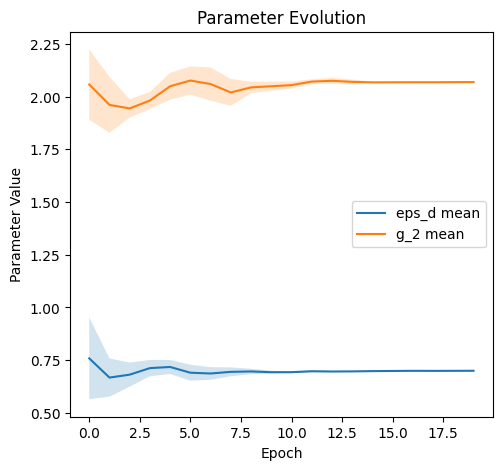

In [37]:
# Plotting results
mean_history = jnp.array(mean_history)
std_history = jnp.array(std_history)
reward_history = jnp.array(reward_history)
reward_std_history = jnp.array(reward_std_history)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Parameter Evolution")
plt.plot(mean_history[:, 0], label="eps_d mean")
plt.plot(mean_history[:, 1], label="g_2 mean")
plt.fill_between(
    jnp.arange(N_EPOCHS),
    mean_history[:, 0] - std_history[:, 0],
    mean_history[:, 0] + std_history[:, 0],
    alpha=0.2
)
plt.fill_between(
    jnp.arange(N_EPOCHS),
    mean_history[:, 1] - std_history[:, 1],
    mean_history[:, 1] + std_history[:, 1],
    alpha=0.2
)
plt.xlabel("Epoch")
plt.ylabel("Parameter Value")
plt.legend()

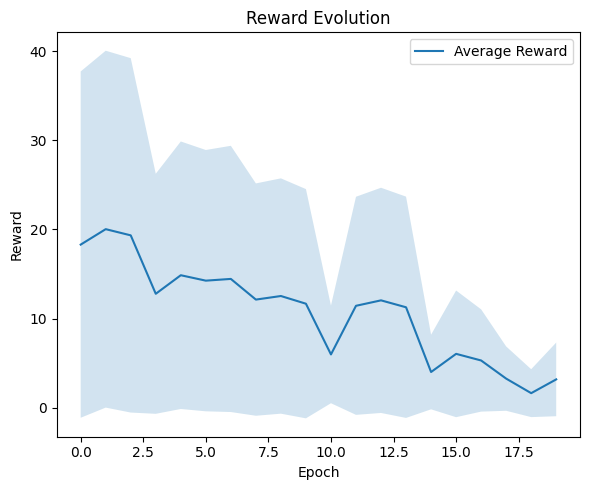

In [40]:
# Plotting reward
plt.figure(figsize=(6, 5))
plt.title("Reward Evolution")
plt.plot(jnp.log(reward_history), label="Average Reward")
plt.fill_between(
    jnp.arange(N_EPOCHS),
    jnp.log(reward_history) - jnp.log(reward_std_history),
    jnp.log(reward_history) + jnp.log(reward_std_history),
    alpha=0.2
)
plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.legend()
plt.tight_layout()
plt.show()